# Modelado Base Reforzado - ALDIMI Demand

En esta versión, hemos incluido **Variables de Memoria (Lags)** para que los modelos puedan capturar tendencias. Esto solucionará el problema de overfitting detectado anteriormente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

# 1. Cargar Datos
BASE_DIR = Path(".").resolve().parent
DATA_PATH = BASE_DIR / "datos" / "datos_modelo1" / "processed" / "aldimi_demanda_dataset_clean.csv"

df = pd.read_csv(DATA_PATH)
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha')

print(f"Dataset cargado con {len(df)} registros.")

Dataset cargado con 2099 registros.


## Ingeniería de Features para Predicción a Futuro

Para predecir a 7 y 14 días, crearemos variables que representen 'lo que sabemos hoy'.

In [2]:
def preparar_datos_horizonte(df, drug, h):
    df_h = df.copy()
    
    # El Target es la demanda dentro de 'h' días
    df_h['target'] = df_h[f'{drug}_demand'].shift(-h)
    
    # --- FEATURES DE MEMORIA (Clave para evitar el error anterior) ---
    # Usamos la demanda de HOY como predictor del futuro
    df_h['demanda_hoy'] = df_h[f'{drug}_demand']
    
    # Promedio móvil de los últimos 7 días (Captura la tendencia actual)
    df_h['promedio_semanal'] = df_h[f'{drug}_demand'].rolling(window=7).mean()
    
    # Limpiar NAs generados por el shift y el rolling
    df_h = df_h.dropna().copy()
    
    # Definir variables predictoras finales
    features = ['n_low', 'n_medium', 'n_high', 'dia_semana', 'es_fin_de_semana', 
                'demanda_hoy', 'promedio_semanal']
    
    # División Cronológica (80% Entrenamiento, 20% Prueba)
    train_size = int(len(df_h) * 0.8)
    train = df_h.iloc[:train_size]
    test = df_h.iloc[train_size:]
    
    return train[features], train['target'], test[features], test['target'], test['fecha']

## Entrenamiento y Evaluación

Probaremos la Regresión Lineal y el Árbol de Decisión (con profundidad optimizada).

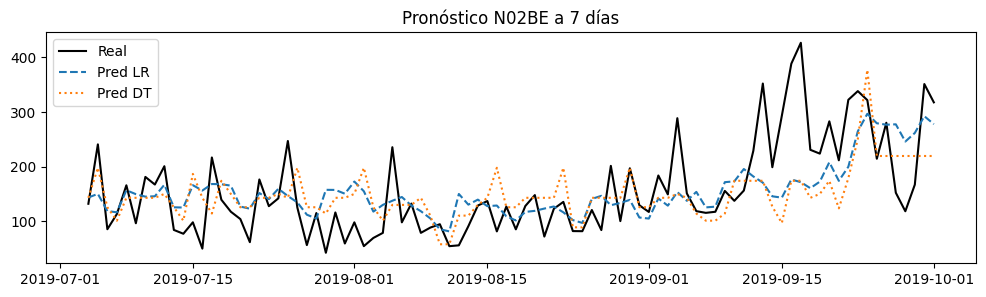

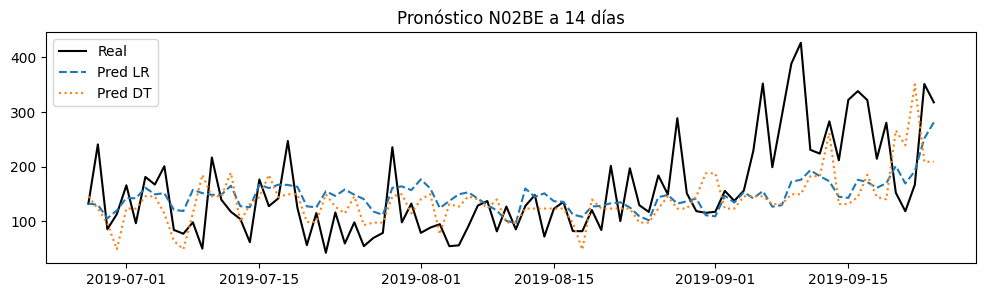

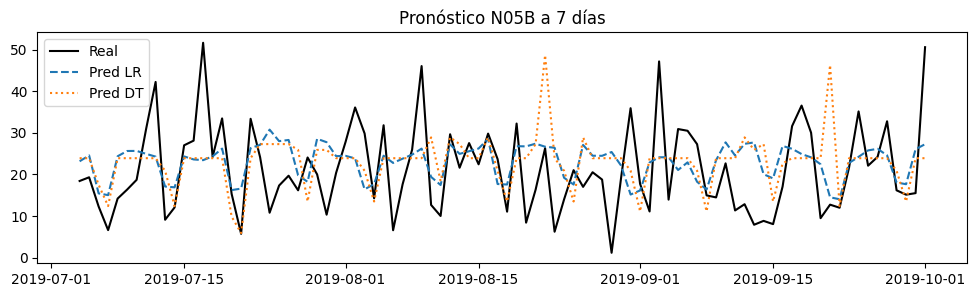

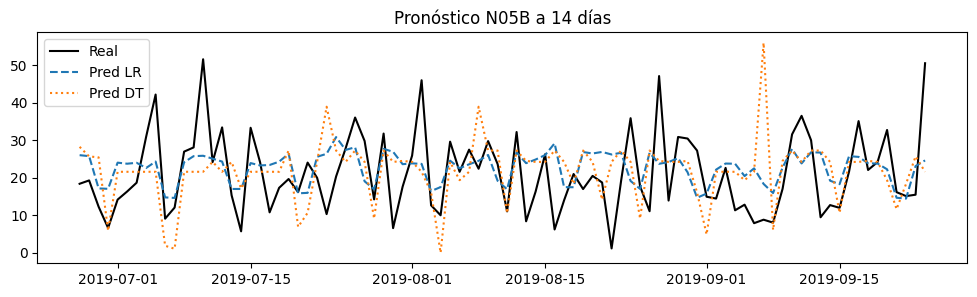

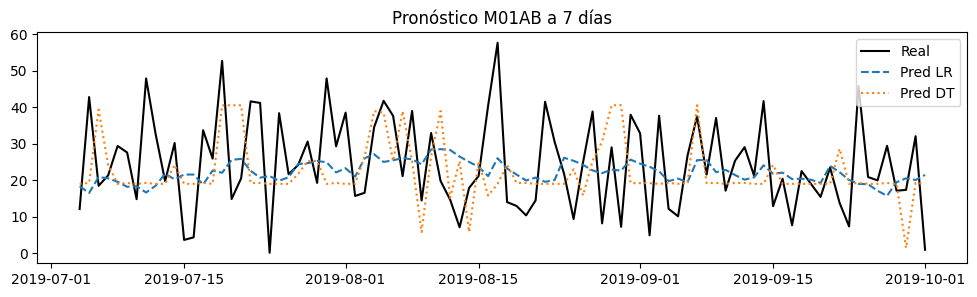

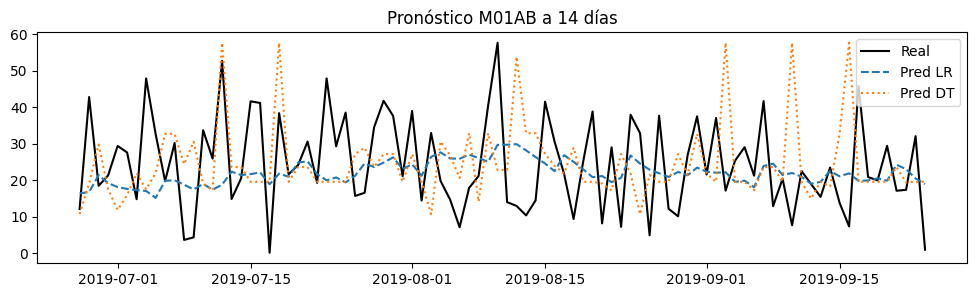

,Medicina,Horizonte,Modelo,MAE,R2
0,N02BE,7d,LR,61.499188,0.300736
1,N02BE,7d,DT,66.821567,0.134711
2,N02BE,14d,LR,64.835154,0.225690
3,N02BE,14d,DT,77.986883,-0.156895
4,N05B,7d,LR,9.550428,0.049188
5,N05B,7d,DT,10.803250,-0.281416
6,N05B,14d,LR,9.492736,0.081004
7,N05B,14d,DT,10.995338,-0.231690
8,M01AB,7d,LR,9.982310,0.033975
9,M01AB,7d,DT,11.742540,-0.433532


In [3]:
drugs = ['N02BE', 'N05B', 'M01AB']
horizons = [7, 14]
results = []

for drug in drugs:
    for h in horizons:
        X_train, y_train, X_test, y_test, dates_test = preparar_datos_horizonte(df, drug, h)
        
        # 1. Linear Regression
        model_lr = LinearRegression()
        model_lr.fit(X_train, y_train)
        y_pred_lr = model_lr.predict(X_test)
        
        model_dt = DecisionTreeRegressor(max_depth=8, random_state=42)
        model_dt.fit(X_train, y_train)
        y_pred_dt = model_dt.predict(X_test)
        
        # Guardar resultados
        for name, pred in [('LR', y_pred_lr), ('DT', y_pred_dt)]:
            results.append({
                'Medicina': drug, 'Horizonte': f'{h}d', 'Modelo': name,
                'MAE': mean_absolute_error(y_test, pred),
                'R2': r2_score(y_test, pred)
            })
            
        # Gráfico de líneas (Últimos 30 días)
        plt.figure(figsize=(12, 3))
        plt.plot(dates_test.iloc[-90:], y_test.iloc[-90:], label='Real', color='black', linewidth=1.5)
        plt.plot(dates_test.iloc[-90:], y_pred_lr[-90:], label='Pred LR', linestyle='--')
        plt.plot(dates_test.iloc[-90:], y_pred_dt[-90:], label='Pred DT', linestyle=':')
        plt.title(f'Pronóstico {drug} a {h} días')
        plt.legend()
        plt.show()


results_df = pd.DataFrame(results)
display(results_df)

In [5]:
import joblib
import os

if not os.path.exists('../modelos'):
    os.makedirs('../modelos')

print("Iniciando exportación de modelos (LR)...")

for drug in drugs:
    for h in horizons:
        X_train, y_train, X_test, y_test, dates_test = preparar_datos_horizonte(df, drug, h)
        
        model_final = LinearRegression()
        model_final.fit(X_train, y_train)
        
        nombre_archivo = f'../modelos/modelo_demanda_{drug}_{h}dias.joblib'
        
        joblib.dump(model_final, nombre_archivo)
        print(f"✅ Exportado: {nombre_archivo}")

print("\n--- ¡Todos los modelos de demanda han sido guardados en /modelos/ ---")


Iniciando exportación de modelos (LR)...
✅ Exportado: ../modelos/modelo_demanda_N02BE_7dias.joblib
✅ Exportado: ../modelos/modelo_demanda_N02BE_14dias.joblib
✅ Exportado: ../modelos/modelo_demanda_N05B_7dias.joblib
✅ Exportado: ../modelos/modelo_demanda_N05B_14dias.joblib
✅ Exportado: ../modelos/modelo_demanda_M01AB_7dias.joblib
✅ Exportado: ../modelos/modelo_demanda_M01AB_14dias.joblib

--- ¡Todos los modelos de demanda han sido guardados en /modelos/ ---
